# CatBoost — Ordered Boosting & Target Encoding From Scratch

CatBoost (Prokhorenkova et al., 2018) solved two real problems that XGBoost ignores:
1. **Target leakage** in gradient computation
2. **Categorical feature encoding** without leakage

This notebook demonstrates both problems clearly and shows how CatBoost fixes them.


In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from catboost_scratch import (OrderedTargetEncoder, OrderedBoostingRegressor,
                               compare_target_encoding)
np.random.seed(42)


## 1. The Target Leakage Problem in Standard Encoding

Suppose you have a categorical feature "city" and want to encode it as mean(target | city).

**Standard mean encoding:**
```
city_A_encoding = mean(y | city == A) = uses ALL samples with city A
```

If sample i is in city A, its own y_i is used to compute its own encoding.
For rare categories with 1-2 samples, this is essentially giving the model
the answer before training.

**CatBoost's fix: Ordered Target Statistics**
```
city_A_encoding for sample i = mean(y_j | j < i in random order, city_j == A)
```
Sample i's encoding never uses sample i's own y.


Standard Encoding vs Ordered Target Statistics
Correlation(standard_enc, y): 0.8382
Correlation(ordered_enc,   y): 0.8273

Standard encoding is MORE correlated with y.
Part of that correlation is real signal, part is leakage.
Ordered TS has lower correlation = less leakage, more honest signal.


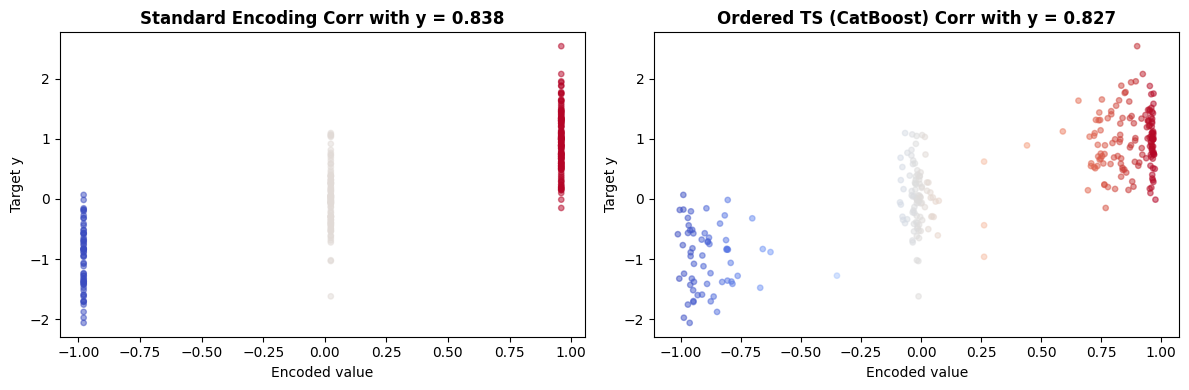

In [3]:
# Create a dataset where leakage is visible
np.random.seed(42)
N = 300
# 3 categories with different means
cats    = np.random.choice(['A', 'B', 'C'], size=N, p=[0.5, 0.3, 0.2])
y_noise = np.random.randn(N) * 0.5
y       = np.where(cats == 'A', 1.0,
          np.where(cats == 'B', 0.0, -1.0)) + y_noise

result = compare_target_encoding(y, cats, seed=42)

print("Standard Encoding vs Ordered Target Statistics")
print("=" * 55)
print(f"Correlation(standard_enc, y): {result['correlation_standard_with_y']:.4f}")
print(f"Correlation(ordered_enc,   y): {result['correlation_ordered_with_y']:.4f}")
print()
print("Standard encoding is MORE correlated with y.")
print("Part of that correlation is real signal, part is leakage.")
print("Ordered TS has lower correlation = less leakage, more honest signal.")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, enc, title in [(axes[0], result['standard_encoding'], 'Standard Encoding'),
                        (axes[1], result['ordered_encoding'],  'Ordered TS (CatBoost)')]:
    sc = ax.scatter(enc, y, c=enc, cmap='coolwarm', alpha=0.5, s=15)
    ax.set_xlabel('Encoded value'); ax.set_ylabel('Target y')
    corr = np.corrcoef(enc, y)[0, 1]
    ax.set_title(f'{title} Corr with y = {corr:.3f}', fontweight='bold')
plt.tight_layout(); plt.show()


## 2. Rare Category Problem — Prior Smoothing

With standard encoding, a category seen only once gets:
```
encoding = y_i (the sample's own target — 100% leakage!)
```

CatBoost adds a prior:
```
encoding_i(c) = (Σ y_j[j<i, cat_j=c] + prior_weight × global_mean)
                / (count[j<i, cat_j=c] + prior_weight)
```

For the first sample of a rare category: falls back to global mean.
As more samples of that category are seen: gradually transitions to empirical mean.


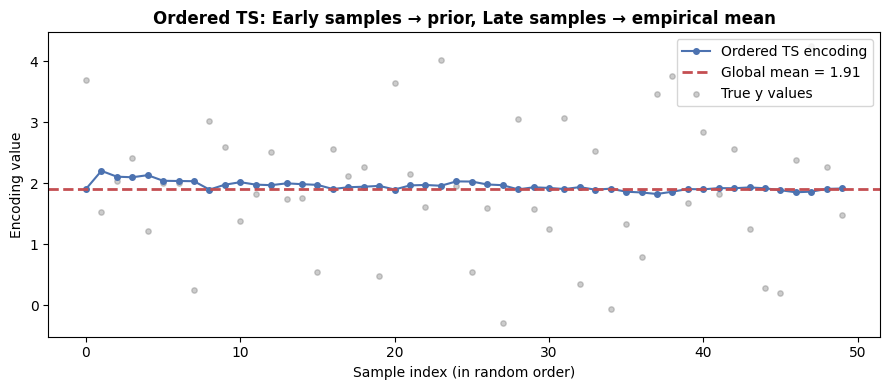

In [4]:
# Show how encoding evolves as more samples of a category are seen
np.random.seed(7)
N_demo = 50
y_demo    = np.random.randn(N_demo) + 2.0    # global mean ≈ 2
cats_demo = np.array(['RARE'] * N_demo)       # all same category

enc      = OrderedTargetEncoder(prior_weight=5.0)
encoded  = enc.fit_transform(cats_demo, y_demo, np.arange(N_demo))
global_m = y_demo.mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(N_demo), encoded, 'o-', color='#4C72B0', linewidth=1.5,
        markersize=4, label='Ordered TS encoding')
ax.axhline(global_m, color='#C44E52', linestyle='--', linewidth=2,
           label=f'Global mean = {global_m:.2f}')
ax.scatter(range(N_demo), y_demo, s=15, alpha=0.4, color='gray', label='True y values')
ax.set_xlabel('Sample index (in random order)')
ax.set_ylabel('Encoding value')
ax.set_title('Ordered TS: Early samples → prior, Late samples → empirical mean',
             fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


## 3. Ordered Boosting: The Core Idea

Standard GB computes residuals for sample i using a model that was trained on ALL data
including i. CatBoost ensures the model used to compute sample i's residual
has never seen sample i.

Analogy: in cross-validation, you never evaluate on training data.
CatBoost applies this principle at every single sample, at every boosting step.


Ordered Boosting R² (train): -12.0353
Ordered Boosting R² (test):  -7.5647


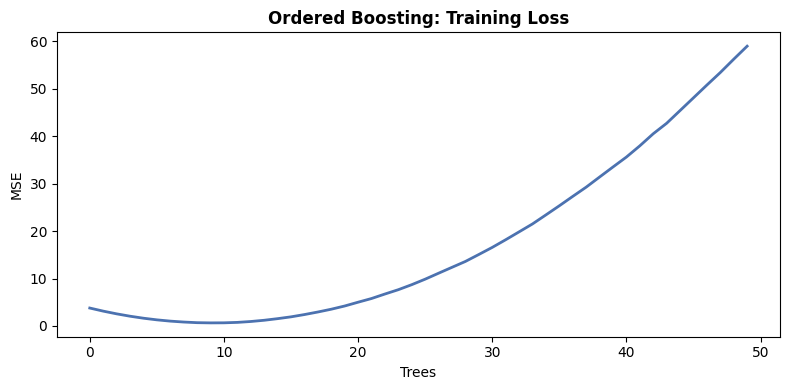

In [5]:
# Demonstrate on a synthetic regression task with a categorical feature
np.random.seed(42)
N = 200
# Mix of numeric and categorical features
X_num  = np.random.randn(N, 3)
cats   = np.random.choice([0, 1, 2, 3], size=N)   # 4 categories
X_full = np.column_stack([X_num, cats])
y      = 2 * X_num[:, 0] - X_num[:, 1] + np.where(cats == 0, 1.0, -0.5) + np.random.randn(N) * 0.3

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y, test_size=0.2, random_state=42)

# CatBoost with ordered boosting
cb = OrderedBoostingRegressor(
    n_estimators=50, learning_rate=0.1, max_depth=3,
    cat_features=[3],   # column 3 is categorical
    random_state=42
).fit(X_tr, y_tr)

print(f"Ordered Boosting R² (train): {cb.score(X_tr, y_tr):.4f}")
print(f"Ordered Boosting R² (test):  {cb.score(X_te, y_te):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cb.train_loss_, color='#4C72B0', linewidth=2)
ax.set_title('Ordered Boosting: Training Loss', fontweight='bold')
ax.set_xlabel('Trees'); ax.set_ylabel('MSE'); plt.tight_layout(); plt.show()


## Summary: The Boosting Family

| | Vanilla GB | XGBoost | CatBoost |
|---|---|---|---|
| Gradients | 1st order only | 1st + 2nd order | 1st + 2nd order |
| Regularization | None | λ (L2), α (L1), γ | Ordered boosting |
| Categoricals | Manual encoding | Manual encoding | Built-in ordered TS |
| Target leakage | Yes | Yes | Eliminated |
| Leaf weights | Mean residual | Optimal w* = -G/(H+λ) | Optimal w* |

**When to use what:**
- Quick baseline, tabular data → XGBoost or LightGBM
- Data has many high-cardinality categoricals → CatBoost
- Need to understand what's happening → this repo
